# MLP con Unrolled Training (Subspace Neural Physics)

## Qué cambia respecto a `rnn03_unrollPos_gpu.ipynb`

Se sustituye la **RNNCell** por una **MLP** (red feed-forward multicapa).

**Por qué MLP:**  
- No tiene estado oculto — toma la ventana completa `[seq_len, V, F]` aplanada como entrada.  
- Holden et al. (2019) usa exactamente este diseño y lo prefiere frente a RNN/GRU/LSTM porque los sistemas físicos pueden describirse completamente con posición y velocidad.  
- La ausencia de estado oculto simplifica la exportación ONNX y la inferencia en Unity.  
- Entrenamiento más estable: sin riesgo de dying neurons ni gradientes que desaparecen a través de pasos de tiempo recurrentes.

**Toggle de unrolling:**  
La variable `USE_UNROLLING` en la celda de entrenamiento permite comparar fácilmente:
- `True` → Rollout completo (BPTT, igual que el paper)  
- `False` → Loss de un solo frame (más rápido, útil como baseline o en datasets pequeños)


---
## 1. Carga de datos
*(Idéntico a rnn01)*

Previa comprobación de si se puede ejecutar en GPU. 

In [9]:
import torch
import subprocess

print("=== PyTorch ===")
print(f"Versión: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"Número de GPUs: {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    print(f"\n--- GPU {i} ---")
    print(f"  Nombre: {torch.cuda.get_device_name(i)}")
    print(f"  Capability: {torch.cuda.get_device_capability(i)}")
    free, total = torch.cuda.mem_get_info(i)
    print(f"  VRAM: {free/1e9:.1f} GB libre / {total/1e9:.1f} GB total")

print("\n=== nvidia-smi ===")
result = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True)
print(result.stdout)

print("=== Test tensor en GPU ===")
x = torch.tensor([1.0]).cuda()
print(f"Tensor en: {x.device}")
print(f"GPU activa: {torch.cuda.get_device_name(torch.cuda.current_device())}")

=== PyTorch ===
Versión: 2.5.0
CUDA disponible: True
Número de GPUs: 1

--- GPU 0 ---
  Nombre: NVIDIA GeForce RTX 5060 Laptop GPU
  Capability: (12, 0)
  VRAM: 6.8 GB libre / 8.5 GB total

=== nvidia-smi ===
GPU 0: NVIDIA GeForce RTX 5060 Laptop GPU (UUID: GPU-58c89557-48ce-2dc5-4340-3f98c03fb31e)

=== Test tensor en GPU ===
Tensor en: cuda:0
GPU activa: NVIDIA GeForce RTX 5060 Laptop GPU


In [10]:
import torch
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # Fuerza device 0 (en mi caso rtx 5060)
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU is not available, using CPU")

print(torch.cuda.get_device_name(0)) 
print(torch.cuda.mem_get_info())        # memoria libre / total de la GPU
print(f"Usando device: {torch.cuda.current_device()}")

GPU is available
NVIDIA GeForce RTX 5060 Laptop GPU
(6758072320, 8546484224)
Usando device: 0


In [ ]:
import pandas as pd
import numpy as np
import json
from torch.utils.data import Dataset, DataLoader

csv_path = 'data/clothDataset_107_.csv'
df = pd.read_csv(csv_path)

num_vertices = 6
num_features = 4  # x, y, z, sdf

selected_columns = []
for i in range(num_vertices):
    selected_columns.extend([f'x{i}', f'y{i}', f'z{i}', f'sdf{i}'])

df_filtered = df[selected_columns]
data_flat = df_filtered.values
num_frames = data_flat.shape[0]

data_3d = data_flat.reshape((num_frames, num_vertices, num_features))
data_tensor = torch.tensor(data_3d, dtype=torch.float32)

print(f"Frames totales: {num_frames}")
print(f"Tensor shape: {data_tensor.shape}  # [Frames, Vertices, Features]")


Frames totales: 25005
Tensor shape: torch.Size([25005, 25, 4])  # [Frames, Vertices, Features]


---
## 2. Dataset con ventana de rollout

Cada item devuelve `seq_len` frames de historia + `rollout_steps` frames futuros.
El training loop usará esos frames futuros para calcular el loss acumulado.

In [12]:
class ClothUnrolledDataset(Dataset):
    """
    Devuelve:
      - sequence:      [seq_len, Vertices, Features]   <- historia conocida
      - future_frames: [rollout_steps, Vertices, Features] <- W frames futuros reales
    """
    def __init__(self, data_frames, seq_len=5, rollout_steps=8):
        if not isinstance(data_frames, torch.Tensor):
            self.data = torch.tensor(data_frames, dtype=torch.float32)
        else:
            self.data = data_frames
        self.seq_len = seq_len
        self.rollout_steps = rollout_steps

    def __len__(self):
        # Necesitamos seq_len frames de historia + rollout_steps frames futuros
        return len(self.data) - self.seq_len - self.rollout_steps

    def __getitem__(self, idx):
        sequence     = self.data[idx : idx + self.seq_len]                          # [seq_len, V, F]
        future_frames = self.data[idx + self.seq_len :                              # [rollout, V, F]
                                  idx + self.seq_len + self.rollout_steps]
        return sequence, future_frames


SEQ_LEN      = 16  # frames de historia que ve la RNN
ROLLOUT_STEPS = 24 # W del paper: cuántos pasos futuros se predicen durante training
BATCH_SIZE   = 32

dataset = ClothUnrolledDataset(data_tensor, seq_len=SEQ_LEN, rollout_steps=ROLLOUT_STEPS)

# Split cronológico (más honesto para física temporal)
train_size = int(0.8 * len(dataset))
train_dataset = torch.utils.data.Subset(dataset, range(train_size))
test_dataset  = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))

pin = device.type == "cuda"
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=pin, persistent_workers=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=pin, persistent_workers=False)

# Verificar shapes
seq_b, fut_b = next(iter(train_loader))
print(f"sequence shape:      {seq_b.shape}   # [B, seq_len, V, F]")
print(f"future_frames shape: {fut_b.shape}  # [B, rollout, V, F]")

sequence shape:      torch.Size([32, 16, 25, 4])   # [B, seq_len, V, F]
future_frames shape: torch.Size([32, 24, 25, 4])  # [B, rollout, V, F]


---
## 3. Estadísticas de normalización
*(Se calculan solo sobre train para evitar data leakage)*

In [ ]:
all_inputs  = []
all_targets = []

for batch_seq, batch_future in train_loader:
    all_inputs.append(batch_seq.view(-1, num_features))
    # Usamos el primer frame futuro como referencia del delta para normalización
    last_pos   = batch_seq[:, -1, :, 0:3]
    first_future_pos = batch_future[:, 0, :, 0:3]
    delta = first_future_pos - last_pos
    all_targets.append(delta.view(-1, 3))

full_input  = torch.cat(all_inputs, dim=0)
full_target = torch.cat(all_targets, dim=0)

input_mean  = full_input.mean(dim=0)
input_std   = full_input.std(dim=0).clamp(min=1e-8)
target_mean = full_target.mean(dim=0)
target_std  = full_target.std(dim=0).clamp(min=1e-8)

print("input_mean:",  input_mean)
print("target_mean:", target_mean)

norm_data = {
    "mean":        input_mean.tolist(),
    "std":         input_std.tolist(),
    "target_mean": target_mean.tolist(),
    "target_std":  target_std.tolist()
}
with open("bigrandom2.json", "w") as f:
    json.dump(norm_data, f)
print("Norm params guardados en mlp608.json")

input_mean: tensor([1.0570e-04, 7.4641e-03, 5.1689e-05, 1.0709e+00])
target_mean: tensor([2.6465e-06, 1.5752e-07, 8.3317e-09])
Norm params guardados en bigrandom2.json


---
## 4. Modelo — MLP

La MLP toma toda la ventana temporal aplanada como entrada:
`input_size = seq_len × num_vertices × num_features`

Esto es equivalente a lo que hace la RNN pero sin procesar paso a paso —
el modelo aprende directamente qué patrón de la historia completa es relevante
para predecir el siguiente delta.

**Ventaja sobre RNN en ONNX/Sentis:** sin estado oculto, el grafo ONNX
es una secuencia simple de operaciones matriciales — ningún operador recurrente.
La forma de entrada `[B, seq_len, V, F]` se mantiene igual que en la RNN
para que el código de Unity (ClothML) sea compatible sin cambios.


In [ ]:
import torch.nn as nn

class FlatMLPClothUnity(nn.Module):
    """
    MLP feed-forward que toma toda la ventana temporal aplanada como entrada.

    Input:  [B, seq_len, V, F]  →  se aplana a  [B, seq_len * V * F]
    Output: [B, V, 3]           →  delta XYZ por vértice

    Al no tener estado oculto, el grafo ONNX es una secuencia de
    operaciones matriciales simples, compatible con cualquier versión
    de Unity Inference Engine sin problemas de operadores recurrentes.
    """
    def __init__(self, seq_len, num_vertices, num_features,
                 hidden_size, num_layers=4, num_outputs=3):
        super().__init__()
        self.num_vertices = num_vertices
        self.num_outputs  = num_outputs
        self.seq_len      = seq_len

        input_size = seq_len * num_vertices * num_features  # ventana completa aplanada

        # Bloque de capas ocultas
        layers = [nn.Linear(input_size, hidden_size), nn.ReLU()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.ReLU()]
        layers.append(nn.Linear(hidden_size, num_vertices * num_outputs))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """
        x: [Batch, seq_len, Vertices, Features]
        returns pred_delta: [Batch, Vertices, 3]
        """
        B = x.shape[0]
        x_flat = x.view(B, -1)                              # [B, seq_len*V*F]
        out    = self.net(x_flat)                           # [B, V*3]
        return out.view(B, self.num_vertices, self.num_outputs)


HIDDEN_SIZE = 128
NUM_LAYERS  = 4   # número de capas ocultas (Holden usa 10, 4 es un buen punto de partida)

model = FlatMLPClothUnity(
    seq_len=SEQ_LEN,
    num_vertices=num_vertices,
    num_features=num_features,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    num_outputs=3
)

model = model.to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parámetros totales: {total_params:,}")
print(f"Modelo en: {next(model.parameters()).device}")
print(f"Input size por muestra: {SEQ_LEN * num_vertices * num_features}")


Parámetros totales: 626,507
Modelo en: cuda:0
Input size por muestra: 1600


In [15]:
import threading, time

def monitor_gpu(stop_event):
    while not stop_event.is_set():
        mem = torch.cuda.memory_allocated() / 1e9
        reserved = torch.cuda.memory_reserved() / 1e9
        print(f"  GPU mem: {mem:.2f} GB allocated | {reserved:.2f} GB reserved", flush=True)
        time.sleep(5)

stop_event = threading.Event()
monitor_thread = threading.Thread(target=monitor_gpu, args=(stop_event,))
monitor_thread.start()

# ... aquí va tu loop de entrenamiento ...

stop_event.set()
monitor_thread.join()

  GPU mem: 0.03 GB allocated | 0.06 GB reserved


---
## 5. Training Loop con toggle de unrolling

La variable `USE_UNROLLING` controla el modo de entrenamiento:

| `USE_UNROLLING` | Comportamiento | Cuándo usarlo |
|---|---|---|
| `True` | Rollout completo W pasos (BPTT) | Resultado final, mayor estabilidad autoregresiva |
| `False` | Loss de un solo frame siguiente | Baseline rápido, datasets pequeños, debug |

```
# Con unrolling (USE_UNROLLING = True):
for k in range(W):
    pred_delta = model(window_norm)       # MLP sobre ventana completa
    pred_pos   = last_pos + denorm(pred_delta)
    window     = slide(window, pred_pos)  # ventana se desliza con la predicción
    loss      += L1(pred_delta, real_delta) + L1(pred_vel, real_vel)
loss /= W

# Sin unrolling (USE_UNROLLING = False):
pred_delta = model(window_norm)           # solo un paso
loss = L1(pred_delta, real_delta) + L1(pred_vel, real_vel)
```


In [16]:
# Mover estadísticas de normalización al mismo device que el modelo
input_mean  = input_mean.to(device)
input_std   = input_std.to(device)
target_mean = target_mean.to(device)
target_std  = target_std.to(device)

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)

EPOCHS      = 50
NOISE_SIGMA = 0.03
VEL_WEIGHT  = 1.0

# ── Toggle de unrolling ───────────────────────────────────────────────────────
# True  → rollout completo W pasos con BPTT (igual que el paper, más estable)
# False → loss de un solo frame siguiente (más rápido, útil como baseline)
USE_UNROLLING = True
# ─────────────────────────────────────────────────────────────────────────────

# ── Early stopping ────────────────────────────────────────────────────────────
PATIENCE          = 30
MIN_DELTA         = 1e-6
best_test_loss    = float('inf')
epochs_no_improve = 0
best_model_state  = None
# ─────────────────────────────────────────────────────────────────────────────

def norm_input(x):
    return (x - input_mean) / input_std

def denorm_delta(d):
    return d * target_std + target_mean

def norm_delta(d):
    return (d - target_mean) / target_std


def run_single_step(batch_seq, batch_future, add_noise=False):
    """
    Loss de un solo frame: predice únicamente el frame siguiente.
    Más rápido que el rollout pero el modelo no aprende a corregir
    errores acumulados durante la autoregresión en inferencia.
    """
    window = batch_seq.clone()

    if add_noise:
        noise = torch.randn_like(window[:, -2:, :, :]) * NOISE_SIGMA
        window[:, -2:, :, :] = window[:, -2:, :, :] + noise

    window_norm     = norm_input(window)
    pred_delta_norm = model(window_norm)             # [B, V, 3]

    last_pos         = window[:, -1, :, 0:3]
    real_pos         = batch_future[:, 0, :, 0:3]
    real_delta       = real_pos - last_pos
    real_delta_norm  = norm_delta(real_delta)
    loss_pos         = criterion(pred_delta_norm, real_delta_norm)

    # Velocidad
    pred_delta_real = denorm_delta(pred_delta_norm)
    pred_pos        = last_pos + pred_delta_real
    real_prev_pos   = batch_seq[:, -1, :, 0:3]
    pred_vel        = pred_pos - real_prev_pos
    real_vel        = real_pos - real_prev_pos
    loss_vel = criterion(
        pred_vel / target_std.clamp(min=1e-8),
        real_vel / target_std.clamp(min=1e-8)
    )

    return loss_pos + VEL_WEIGHT * loss_vel


def run_rollout(batch_seq, batch_future, add_noise=False):
    """
    Rollout completo W pasos con BPTT.
    El gradiente fluye hacia atrás a través de toda la cadena de predicciones,
    forzando a la MLP a aprender correcciones pequeñas y estables.

    batch_seq:    [B, seq_len, V, F]
    batch_future: [B, rollout, V, F]
    """
    B, W, V, F = batch_future.shape
    window      = batch_seq.clone()

    if add_noise:
        noise = torch.randn_like(window[:, -2:, :, :]) * NOISE_SIGMA
        window[:, -2:, :, :] = window[:, -2:, :, :] + noise

    total_loss    = torch.tensor(0.0, device=batch_seq.device)
    prev_pred_pos = window[:, -1, :, 0:3]

    for k in range(W):
        # ── Forward ────────────────────────────────────────────────
        window_norm     = norm_input(window)
        pred_delta_norm = model(window_norm)             # [B, V, 3]

        last_pos        = window[:, -1, :, 0:3]
        pred_delta_real = denorm_delta(pred_delta_norm)
        pred_pos        = last_pos + pred_delta_real     # [B, V, 3]

        # ── Targets ────────────────────────────────────────────────
        real_pos      = batch_future[:, k, :, 0:3]
        real_prev_pos = (batch_future[:, k-1, :, 0:3] if k > 0
                         else batch_seq[:, -1, :, 0:3])

        # ── Loss posición ──────────────────────────────────────────
        real_delta      = real_pos - last_pos
        real_delta_norm = norm_delta(real_delta)
        loss_pos = criterion(pred_delta_norm, real_delta_norm)

        # ── Loss velocidad ─────────────────────────────────────────
        pred_vel = pred_pos - prev_pred_pos
        real_vel = real_pos - real_prev_pos
        loss_vel = criterion(
            pred_vel / target_std.clamp(min=1e-8),
            real_vel / target_std.clamp(min=1e-8)
        )

        total_loss = total_loss + loss_pos + VEL_WEIGHT * loss_vel

        # ── Deslizar ventana ────────────────────────────────────────
        new_frame = window[:, -1, :, :].clone()
        new_frame[:, :, 0:3] = pred_pos.detach() if not model.training else pred_pos
        new_frame[:, :, 3]   = batch_future[:, k, :, 3]  # SDF real del frame k
        window = torch.cat([window[:, 1:, :, :], new_frame.unsqueeze(1)], dim=1)

        prev_pred_pos = pred_pos

    return total_loss / W


def compute_loss(batch_seq, batch_future, add_noise=False):
    """Despacha a run_single_step o run_rollout según USE_UNROLLING."""
    if USE_UNROLLING:
        return run_rollout(batch_seq, batch_future, add_noise)
    else:
        return run_single_step(batch_seq, batch_future, add_noise)


# ==============================================================================
# BUCLE DE ENTRENAMIENTO
# ==============================================================================
history = {'train': [], 'test': [], 'vertex_error': []}
print(f"Modo: {'UNROLLING activado (W={ROLLOUT_STEPS})' if USE_UNROLLING else 'Single-step (sin unrolling)'}")

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for batch_seq, batch_future in train_loader:
        batch_seq    = batch_seq.float().to(device, non_blocking=True)
        batch_future = batch_future.float().to(device, non_blocking=True)

        loss = compute_loss(batch_seq, batch_future, add_noise=True)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    avg_train = train_loss / len(train_loader)

    # ── TEST ─────────────────────────────────────────────────────
    model.eval()
    test_loss   = 0.0
    total_err   = 0.0
    total_verts = 0
    all_pred_pos   = []
    all_target_pos = []

    with torch.no_grad():
        for batch_seq, batch_future in test_loader:
            batch_seq    = batch_seq.float().to(device, non_blocking=True)
            batch_future = batch_future.float().to(device, non_blocking=True)

            loss = compute_loss(batch_seq, batch_future, add_noise=False)
            test_loss += loss.item()

            # Métrica: error en el primer frame predicho
            window_norm = norm_input(batch_seq)
            pred_dn     = model(window_norm)
            last_pos    = batch_seq[:, -1, :, 0:3]
            pred_pos    = last_pos + denorm_delta(pred_dn)
            target_pos  = batch_future[:, 0, :, 0:3]

            all_pred_pos.append(pred_pos.detach().cpu().numpy())
            all_target_pos.append(target_pos.detach().cpu().numpy())

            distances    = torch.norm(pred_pos - target_pos, dim=-1)
            total_err   += distances.sum().item()
            total_verts += distances.numel()

    avg_test     = test_loss  / len(test_loader)
    avg_vert_err = total_err  / total_verts

    history['train'].append(avg_train)
    history['test'].append(avg_test)
    history['vertex_error'].append(avg_vert_err)

    preds_pos_np   = np.concatenate(all_pred_pos,   axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train: {avg_train:.6f} | "
              f"Test: {avg_test:.6f} | VertErr: {avg_vert_err:.6f} | "
              f"Best: {best_test_loss:.6f} | Patience: {epochs_no_improve}/{PATIENCE}")

    # ── Early stopping ────────────────────────────────────────────
    if avg_test < best_test_loss - MIN_DELTA:
        best_test_loss    = avg_test
        epochs_no_improve = 0
        best_model_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping en epoch {epoch} — sin mejora en {PATIENCE} épocas.")
            print(f"Mejor test loss: {best_test_loss:.6f}")
            break

if best_model_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    print("Modelo restaurado al mejor checkpoint.")

print("\nEntrenamiento completado.")


Modo: UNROLLING activado (W={ROLLOUT_STEPS})
Epoch 001 | Train: 16.850279 | Test: 2.700164 | VertErr: 0.001743 | Best: inf | Patience: 0/30
Epoch 010 | Train: 15.268567 | Test: 2.265240 | VertErr: 0.001371 | Best: 2.182955 | Patience: 4/30
Epoch 020 | Train: 13.267428 | Test: 2.126879 | VertErr: 0.001396 | Best: 2.074564 | Patience: 1/30
Epoch 030 | Train: 12.792415 | Test: 2.108469 | VertErr: 0.001528 | Best: 1.998504 | Patience: 6/30
Epoch 040 | Train: 12.529322 | Test: 2.019377 | VertErr: 0.001582 | Best: 1.923441 | Patience: 5/30
Epoch 050 | Train: 12.316676 | Test: 2.109114 | VertErr: 0.001706 | Best: 1.923441 | Patience: 15/30
Modelo restaurado al mejor checkpoint.

Entrenamiento completado.


In [17]:
'''
# Mover estadísticas de normalización al mismo device que el modelo
input_mean  = input_mean.to(device)
input_std   = input_std.to(device)
target_mean = target_mean.to(device)
target_std  = target_std.to(device)

criterion   = nn.L1Loss()
optimizer   = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler   = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)

EPOCHS      = 300
NOISE_SIGMA = 0.03   # ruido en los 2 frames iniciales (como el paper)
VEL_WEIGHT  = 1.0    # peso del loss de velocidad (Lvel en el paper)

# ─────────────────────────────────────────────────────────────────
# Helpers de normalización / desnormalización
# ─────────────────────────────────────────────────────────────────
def norm_input(x):
    """ x: [..., F=4] """
    return (x - input_mean) / input_std

def denorm_delta(d):
    """ d: [..., 3] """
    return d * target_std + target_mean

def norm_delta(d):
    return (d - target_mean) / target_std

# ─────────────────────────────────────────────────────────────────
# Función de un rollout completo (usada en train y eval)
# ─────────────────────────────────────────────────────────────────
def run_rollout(batch_seq, batch_future, add_noise=False):
    """
    batch_seq:    [B, seq_len, V, F]   — historia inicial
    batch_future: [B, rollout, V, F]   — frames reales futuros
    
    Retorna el loss acumulado (posición + velocidad) sobre los W pasos.
    """
    B, W, V, F = batch_future.shape
    
    # Ventana deslizante de posiciones absolutas  [B, seq_len, V, F]
    # Hacemos clone para no modificar el tensor original (lo necesita pytorch para el backward)
    window = batch_seq.clone()   # [B, seq_len, V, F]

    # Ruido inicial en los 2 últimos frames de la historia (Paper §5.4)
    if add_noise:
        noise = torch.randn_like(window[:, -2:, :, :]) * NOISE_SIGMA
        window[:, -2:, :, :] = window[:, -2:, :, :] + noise

    total_loss = torch.tensor(0.0, device=batch_seq.device)

    prev_pred_pos = window[:, -1, :, 0:3]  # posición del frame t-1 (para vel)

    for k in range(W):
        # ── Forward ────────────────────────────────────────────────
        window_norm = norm_input(window)           # [B, seq_len, V, F]
        pred_delta_norm = model(window_norm)       # [B, V, 3]

        last_pos = window[:, -1, :, 0:3]          # posición del último frame conocido
        pred_delta_real = denorm_delta(pred_delta_norm)   # [B, V, 3]
        pred_pos = last_pos + pred_delta_real      # posición predicha [B, V, 3]

        # ── Targets reales ─────────────────────────────────────────
        real_pos = batch_future[:, k, :, 0:3]     # [B, V, 3]
        real_prev_pos = (
            batch_future[:, k-1, :, 0:3] if k > 0
            else batch_seq[:, -1, :, 0:3]
        )

        # ── Loss posición ──────────────────────────────────────────
        real_delta      = real_pos - last_pos
        real_delta_norm = norm_delta(real_delta)
        loss_pos = criterion(pred_delta_norm, real_delta_norm)

        # ── Loss velocidad (Paper §5.4: Lvel) ──────────────────────
        # velocidad predicha vs real (diferencia de posiciones consecutivas)
        pred_vel = pred_pos - prev_pred_pos        # [B, V, 3]
        real_vel = real_pos - real_prev_pos        # [B, V, 3]
        # normalizamos con target_std para escalar consistente
        loss_vel = criterion(
            pred_vel / target_std.clamp(min=1e-8),
            real_vel / target_std.clamp(min=1e-8)
        )

        total_loss = total_loss + loss_pos + VEL_WEIGHT * loss_vel

        # ── Feedback: pred_pos → nuevo último frame de la ventana ──
        # Construimos el nuevo frame predicho con x,y,z + sdf del real
        # (el sdf no lo predecimos, usamos el real como aprox)
        new_frame = window[:, -1, :, :].clone()   # copia del último frame
        new_frame[:, :, 0:3] = pred_pos.detach() if not model.training else pred_pos
        # Desplazamos la ventana: quitamos el frame más antiguo, añadimos la predicción
        window = torch.cat([window[:, 1:, :, :], new_frame.unsqueeze(1)], dim=1)

        prev_pred_pos = pred_pos

    return total_loss / W


# ─────────────────────────────────────────────────────────────────
# Bucle de entrenamiento
# ─────────────────────────────────────────────────────────────────
history = {'train': [], 'test': [], 'vertex_error': []}

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for batch_seq, batch_future in train_loader:
        batch_seq    = batch_seq.float().to(device, non_blocking=True)
        batch_future = batch_future.float().to(device, non_blocking=True)

        loss = run_rollout(batch_seq, batch_future, add_noise=True)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    scheduler.step()
    avg_train = train_loss / len(train_loader)

    # ── TEST ─────────────────────────────────────────────────────
    model.eval()
    test_loss  = 0.0
    total_err  = 0.0
    total_verts = 0

    all_pred_pos   = []
    all_target_pos = []

    with torch.no_grad():
        for batch_seq, batch_future in test_loader:
            batch_seq    = batch_seq.float().to(device, non_blocking=True)
            batch_future = batch_future.float().to(device, non_blocking=True)

            loss = run_rollout(batch_seq, batch_future, add_noise=False)
            test_loss += loss.item()

            # Para métricas, evaluamos solo el primer frame predicho
            window_norm  = norm_input(batch_seq)
            pred_dn      = model(window_norm)
            last_pos     = batch_seq[:, -1, :, 0:3]
            pred_pos     = last_pos + denorm_delta(pred_dn)
            target_pos   = batch_future[:, 0, :, 0:3]

            all_pred_pos.append(pred_pos.detach().cpu().numpy())
            all_target_pos.append(target_pos.detach().cpu().numpy())

            distances = torch.norm(pred_pos - target_pos, dim=-1)
            total_err   += distances.sum().item()
            total_verts += distances.numel()

    avg_test     = test_loss  / len(test_loader)
    avg_vert_err = total_err  / total_verts


    history['train'].append(avg_train)
    history['test'].append(avg_test)
    history['vertex_error'].append(avg_vert_err)

    preds_pos_np   = np.concatenate(all_pred_pos,   axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    if epoch % 100 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train: {avg_train:.6f} | "
              f"Test: {avg_test:.6f} | VertErr: {avg_vert_err:.6f}")

print("\nEntrenamiento completado.")
'''

'\n# Mover estadísticas de normalización al mismo device que el modelo\ninput_mean  = input_mean.to(device)\ninput_std   = input_std.to(device)\ntarget_mean = target_mean.to(device)\ntarget_std  = target_std.to(device)\n\ncriterion   = nn.L1Loss()\noptimizer   = torch.optim.Adam(model.parameters(), lr=1e-4)\nscheduler   = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)\n\nEPOCHS      = 300\nNOISE_SIGMA = 0.03   # ruido en los 2 frames iniciales (como el paper)\nVEL_WEIGHT  = 1.0    # peso del loss de velocidad (Lvel en el paper)\n\n# ─────────────────────────────────────────────────────────────────\n# Helpers de normalización / desnormalización\n# ─────────────────────────────────────────────────────────────────\ndef norm_input(x):\n    """ x: [..., F=4] """\n    return (x - input_mean) / input_std\n\ndef denorm_delta(d):\n    """ d: [..., 3] """\n    return d * target_std + target_mean\n\ndef norm_delta(d):\n    return (d - target_mean) / target_std\n\n# ───────────────

---
## 6. Visualización de resultados

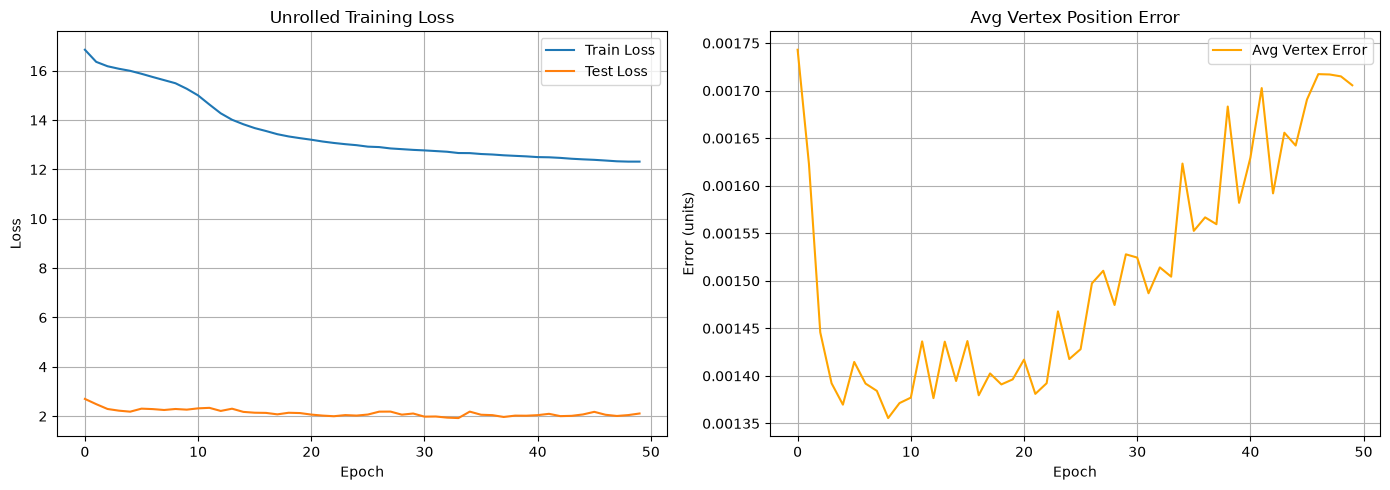

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train'], label='Train Loss')
axes[0].plot(history['test'],  label='Test Loss')
axes[0].set_title('Unrolled Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['vertex_error'], color='orange', label='Avg Vertex Error')
axes[1].set_title('Avg Vertex Position Error')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Error (units)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

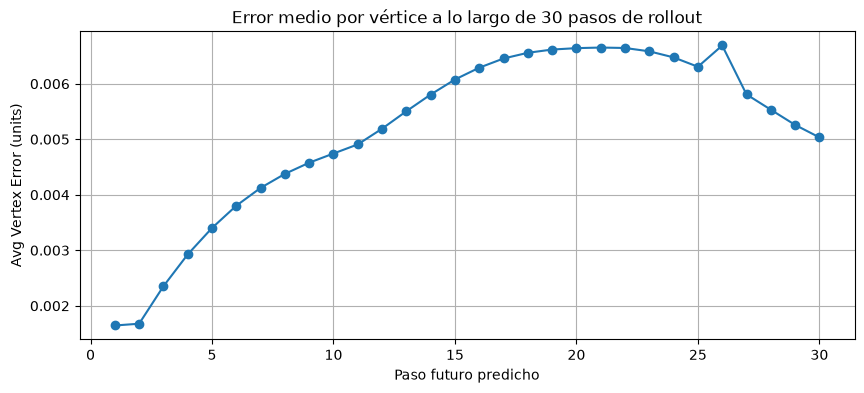

Si la curva crece lentamente → el unrolled training ha funcionado.
Si explota → prueba aumentar ROLLOUT_STEPS o NOISE_SIGMA.


In [19]:
# ─────────────────────────────────────────────────────────────────
# Evaluación del rollout autoregresivo completo sobre una secuencia
# ─────────────────────────────────────────────────────────────────
# Tomamos una secuencia de test y la predecimos N pasos hacia el futuro
# usando SOLO la historia inicial → comprobamos si el error se dispara

model.eval()
N_STEPS = 30  # cuántos pasos predecir en cadena

# Primer batch del test
seq_sample, future_sample = next(iter(test_loader))
seq_sample    = seq_sample[:1].float().to(device)
future_sample = future_sample[:1].float().to(device)

# Datos reales que seguirán (para comparar)
# Buscamos los siguientes N_STEPS frames desde el dataset
start_idx = train_size  # primer índice del test set
end_idx   = start_idx + SEQ_LEN + N_STEPS
real_sequence = data_tensor[start_idx:end_idx].unsqueeze(0).float().to(device)  # [1, SEQ+N, V, F]

rollout_preds = []   # posiciones predichas
rollout_reals = []   # posiciones reales

window = seq_sample.clone()  # [1, seq_len, V, F]

with torch.no_grad():
    for step in range(N_STEPS):
        window_norm  = norm_input(window)
        pred_dn      = model(window_norm)                        # [1, V, 3]
        last_pos     = window[:, -1, :, 0:3]
        pred_pos     = last_pos + denorm_delta(pred_dn)          # [1, V, 3]

        rollout_preds.append(pred_pos.squeeze(0).cpu().numpy())  # [V, 3]
        real_pos = real_sequence[:, SEQ_LEN + step, :, 0:3]
        rollout_reals.append(real_pos.squeeze(0).cpu().numpy())

        # Feedback: insertar predicción en la ventana
        new_frame = window[:, -1, :, :].clone()
        new_frame[:, :, 0:3] = pred_pos
        window = torch.cat([window[:, 1:, :, :], new_frame.unsqueeze(1)], dim=1)

# Error medio por vértice en cada paso del rollout
rollout_errors = [
    np.linalg.norm(rollout_preds[i] - rollout_reals[i], axis=-1).mean()
    for i in range(N_STEPS)
]

plt.figure(figsize=(10, 4))
plt.plot(range(1, N_STEPS+1), rollout_errors, marker='o')
plt.title(f'Error medio por vértice a lo largo de {N_STEPS} pasos de rollout')
plt.xlabel('Paso futuro predicho')
plt.ylabel('Avg Vertex Error (units)')
plt.grid(True)
plt.show()

print("Si la curva crece lentamente → el unrolled training ha funcionado.")
print("Si explota → prueba aumentar ROLLOUT_STEPS o NOISE_SIGMA.")

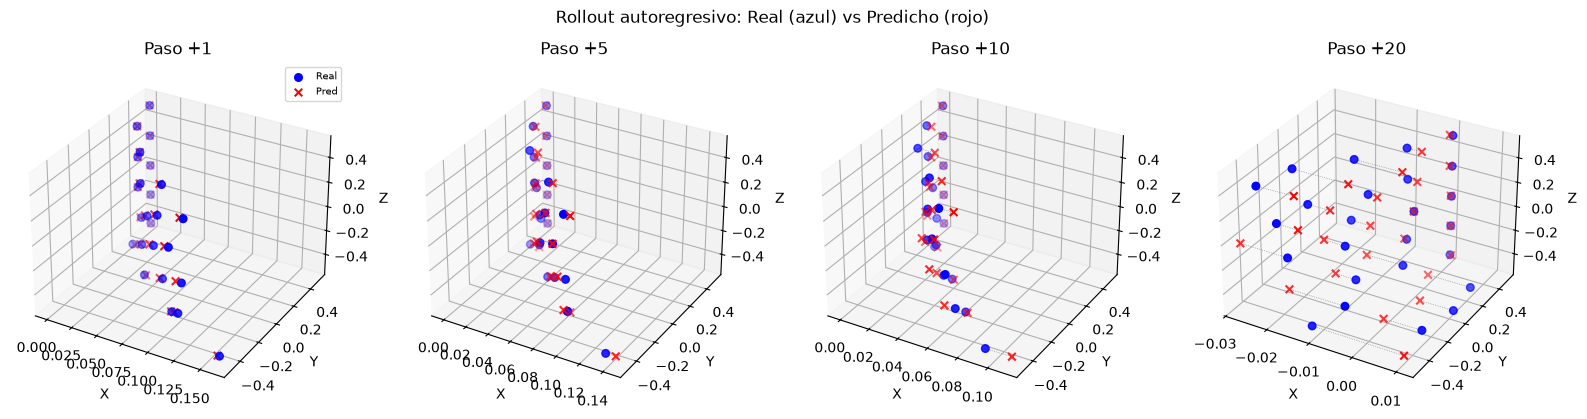

In [20]:
# ─────────────────────────────────────────────────────────────────
# Visualización 3D: shape real vs predicho en varios pasos futuros
# ─────────────────────────────────────────────────────────────────
steps_to_show = [0, 4, 9, 19]  # qué pasos visualizar
fig = plt.figure(figsize=(16, 4))

for col, step in enumerate(steps_to_show):
    ax = fig.add_subplot(1, len(steps_to_show), col+1, projection='3d')
    real = rollout_reals[step]
    pred = rollout_preds[step]

    ax.scatter(real[:, 0], real[:, 1], real[:, 2], c='blue',  s=30, label='Real',  marker='o')
    ax.scatter(pred[:, 0], pred[:, 1], pred[:, 2], c='red',   s=30, label='Pred',  marker='x')

    for i in range(num_vertices):
        ax.plot([real[i,0], pred[i,0]], [real[i,1], pred[i,1]],
                [real[i,2], pred[i,2]], color='gray', linestyle='dotted', linewidth=0.5)

    ax.set_title(f'Paso +{step+1}')
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    if col == 0:
        ax.legend(fontsize=7)

plt.suptitle('Rollout autoregresivo: Real (azul) vs Predicho (rojo)', y=1.01)
plt.tight_layout()
plt.show()

---
## 7. Export a ONNX

La MLP no tiene estado oculto, así que el grafo ONNX es simplemente
una secuencia de operaciones matriciales con ReLU. Compatible con
cualquier versión de Unity Inference Engine sin problemas de operadores
recurrentes (GRU/LSTM). La forma de entrada es idéntica a la RNN —
el código Unity no necesita cambios.


In [ ]:
import torch
import onnx
import onnxruntime

model.eval()
model_cpu = model.cpu()

# Forma de entrada idéntica a la RNN: [Batch=1, seq_len, V, F]
# La MLP la aplana internamente → compatible con el mismo ClothML de Unity
dummy_input = torch.randn(1, SEQ_LEN, num_vertices, num_features)

onnx_program = torch.onnx.export(
    model_cpu,
    dummy_input,
    "mlp608.onnx",
    export_params=True,
    opset_version=15,
    input_names=['input'],
    output_names=['output'],
)

onnx_model = onnx.load("mlp608.onnx")
onnx.checker.check_model(onnx_model)

ort_session = onnxruntime.InferenceSession("mlp608.onnx")
ort_out = ort_session.run(None, {'input': dummy_input.numpy()})
print(f"ONNX output shape: {ort_out[0].shape}")
print("Export exitoso — compatible con Unity Inference Engine (Sentis).")
print(f"Input shape: {dummy_input.shape}")

# Restaurar en device original
model = model_cpu.to(device)


ONNX output shape: (1, 25, 3)
Export exitoso — compatible con Unity Inference Engine (Sentis).
Input shape: torch.Size([1, 16, 25, 4])
